In [9]:
# =========================
# 1) Setup + Load Data
# =========================
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import matplotlib.pyplot as plt


In [8]:
import pandas as pd

# Correct read (TSV)
df = pd.read_csv("marketing_campaign.csv", sep="\t")
print(df.shape)
print(df.columns.tolist()[:10])
df.head()

(2240, 29)
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [10]:
# =========================
# 2) Basic Cleaning + Feature Engineering
# =========================
df = df.copy()

# Parse date and create tenure
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
max_date = df["Dt_Customer"].max()
df["TenureDays"] = (max_date - df["Dt_Customer"]).dt.days

# Age from Year_Birth
CURRENT_YEAR = 2025  # set to current year you want
df["Age"] = CURRENT_YEAR - df["Year_Birth"]

# Drop non-informative constants if present
for col in ["Z_CostContact", "Z_Revenue"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Drop ID from modeling (keep for indexing)
id_col = "ID" if "ID" in df.columns else None

# Basic missing-value handling for Income (common missing field)
if "Income" in df.columns:
    df["Income"] = df["Income"].replace({0: np.nan})
    df["Income"] = df["Income"].fillna(df["Income"].median())

# Optional: clean Marital_Status (often has odd categories)
if "Marital_Status" in df.columns:
    df["Marital_Status"] = df["Marital_Status"].astype(str).str.strip()

# Optional: remove obvious outliers in Income/Age if you want (kept conservative)
df = df[df["Age"].between(18, 100)]
if "Income" in df.columns:
    df = df[df["Income"].between(0, df["Income"].quantile(0.995))]

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (2225, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,TenureDays,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,7,0,0,0,0,0,0,1,971.0,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,5,0,0,0,0,0,0,0,125.0,71
2,4141,1965,Graduation,Together,71613.0,0,0,NaT,26,426,...,4,0,0,0,0,0,0,0,NaN,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,6,0,0,0,0,0,0,0,65.0,41
4,5324,1981,PhD,Married,58293.0,1,0,NaT,94,173,...,5,0,0,0,0,0,0,0,NaN,44


#Dataset Description

In [26]:
import pandas as pd
import numpy as np

# -------------------------
# 1) Basic dataset overview
# -------------------------
print("Shape (rows, cols):", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nData types:\n", df.dtypes)

# -------------------------
# 2) Missing values + duplicates
# -------------------------
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
missing_table = missing_table[missing_table["missing"] > 0]

print("\nMissing values (only cols with missing):")
display(missing_table)

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

# -------------------------
# 3) Quick snapshot
# -------------------------
print("\nHead:")
display(df.head())

print("\nRandom sample:")
display(df.sample(5, random_state=42))

# -------------------------
# 4) Categorical summaries
# -------------------------
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("\nCategorical columns:", cat_cols)

for c in cat_cols:
    print(f"\nTop categories for {c}:")
    display(df[c].value_counts(dropna=False).head(15))

# -------------------------
# 5) Numeric summaries (descriptive stats)
# -------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", num_cols)

desc = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc["IQR"] = desc["75%"] - desc["25%"]
display(desc)

# -------------------------
# 6) Outlier flags (IQR rule) for key variables
# -------------------------
key_outlier_cols = [c for c in ["Income","Age","MntWines","MntMeatProducts","MntGoldProds","NumWebVisitsMonth"] if c in df.columns]
outlier_summary = []

for c in key_outlier_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary.append([c, float(lo), float(hi), int(outliers), round(outliers/len(df)*100, 2)])

outlier_df = pd.DataFrame(outlier_summary, columns=["feature","IQR_lower","IQR_upper","outlier_count","outlier_%"])
print("\nIQR-based outlier summary (selected features):")
display(outlier_df)

# -------------------------
# 7) Marketing-specific derived summaries
# -------------------------
# Total spend across product categories
spend_cols = [c for c in ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"] if c in df.columns]
if spend_cols:
    df["TotalSpend"] = df[spend_cols].sum(axis=1)
    print("\nTotalSpend summary:")
    display(df["TotalSpend"].describe())

# Total purchases by channel
channel_cols = [c for c in ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases"] if c in df.columns]
if channel_cols:
    df["TotalPurchases"] = df[channel_cols].sum(axis=1)
    print("\nTotalPurchases summary:")
    display(df["TotalPurchases"].describe())

# Campaign acceptance rate (AcceptedCmp1..5 + Response)
cmp_cols = [c for c in ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"] if c in df.columns]
if cmp_cols:
    df["TotalCampaignAccepted"] = df[cmp_cols].sum(axis=1)
    print("\nTotalCampaignAccepted distribution:")
    display(df["TotalCampaignAccepted"].value_counts().sort_index())

    print("\nOverall campaign acceptance rate (any acceptance):")
    any_accept = (df["TotalCampaignAccepted"] > 0).mean()
    print(f"{any_accept:.3f} ({any_accept*100:.1f}%)")

# -------------------------
# 8) Correlation (quick, useful for description)
# -------------------------
corr_cols = [c for c in num_cols if c not in ["ID","Year_Birth"]]
corr = df[corr_cols].corr(numeric_only=True)

# Show strongest correlations with Income/TotalSpend if present
targets = [t for t in ["Income","TotalSpend","Response"] if t in corr.columns]
for t in targets:
    print(f"\nTop correlations with {t}:")
    display(corr[t].sort_values(ascending=False).head(12))

Shape (rows, cols): (2225, 29)

Columns:
 ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'TenureDays', 'Age']

Data types:
 ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetPr

,missing,missing_%



Duplicate rows: 0

Head:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,TenureDays,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,1,971,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,0,125,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-07-02 12:00:00,26,426,...,4,0,0,0,0,0,0,0,521,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,0,65,41
4,5324,1981,PhD,Married,58293.0,1,0,2013-07-02 12:00:00,94,173,...,5,0,0,0,0,0,0,0,521,44



Random sample:


...

,count
TotalCampaignAccepted,
0,1620
1,369
2,142
3,50
4,35
5,9



Overall campaign acceptance rate (any acceptance):
0.272 (27.2%)

Top correlations with Income:


,Income
Income,1.000000
MntWines,0.731675
NumCatalogPurchases,0.707706
MntMeatProducts,0.698591
NumStorePurchases,0.685989
MntFishProducts,0.551487
MntSweetProducts,0.544898
MntFruits,0.534439
NumWebPurchases,0.489552
MntGoldProds,0.411365



Top correlations with Response:


,Response
Response,1.000000
AcceptedCmp5,0.320394
AcceptedCmp1,0.285248
AcceptedCmp3,0.255695
MntMeatProducts,0.247118
MntWines,0.244449
NumCatalogPurchases,0.229884
AcceptedCmp4,0.170889
Income,0.168762
AcceptedCmp2,0.163535


In [11]:
# =========================
# 3) Select Features for Segmentation
#    (Demographics + Spend + Channel + Campaign)
# =========================
all_cols = df.columns.tolist()

# Numeric candidates commonly present in this dataset
numeric_candidates = [
    "Income", "Age", "Kidhome", "Teenhome", "Recency", "TenureDays",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5",
    "Response", "Complain"
]
numeric_features = [c for c in numeric_candidates if c in all_cols]

# Categorical candidates
categorical_candidates = ["Education", "Marital_Status"]
categorical_features = [c for c in categorical_candidates if c in all_cols]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

# Build preprocessing
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

X = df.drop(columns=[id_col], errors="ignore")

Numeric: ['Income', 'Age', 'Kidhome', 'Teenhome', 'Recency', 'TenureDays', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']
Categorical: ['Education', 'Marital_Status']


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numeric pipeline: impute -> scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: impute -> one-hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [14]:
# =========================
# 4) Dimensionality Reduction (PCA)
#    Hybrid idea: PCA -> KMeans (global) and Agglomerative (local refinement)
# =========================
# Fit preprocess + PCA
X_proc = preprocess.fit_transform(X)

# Choose PCA components by variance (keep it simple and stable)
pca = PCA(n_components=0.90, random_state=42)  # keep 90% variance
X_pca = pca.fit_transform(X_proc)

print("Processed shape:", X_proc.shape)
print("PCA shape:", X_pca.shape)
print("Explained variance (sum):", pca.explained_variance_ratio_.sum())

Processed shape: (2225, 37)
PCA shape: (2225, 20)
Explained variance (sum): 0.9135472858302469


In [15]:
# =========================
# 5) Pick k (simple search using silhouette)
# =========================
def eval_kmeans(X, k_list):
    rows = []
    for k in k_list:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        rows.append((k, sil, ch, db))
    return pd.DataFrame(rows, columns=["k", "silhouette", "calinski_harabasz", "davies_bouldin"])

k_list = list(range(2, 11))
k_eval = eval_kmeans(X_pca, k_list)
k_eval

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.262924,664.547097,1.705595
1,3,0.232365,460.180554,2.033306
2,4,0.191716,400.605781,2.020177
3,5,0.173002,329.261584,2.162935
4,6,0.115359,293.260918,2.185873
5,7,0.152059,259.899822,2.160440
6,8,0.141241,295.900617,1.655663
7,9,0.112112,267.160282,1.756767
8,10,0.094344,249.542947,1.989712


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

def eval_kmeans(X, k_list):
    rows = []
    for k in k_list:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        rows.append((k, sil, ch, db))
    return pd.DataFrame(rows, columns=["k", "silhouette", "calinski_harabasz", "davies_bouldin"])

k_list = range(2, 11)
k_eval = eval_kmeans(X_pca, k_list)

display(k_eval)

best_k = int(k_eval.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Best k by silhouette:", best_k)

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.262924,664.547097,1.705595
1,3,0.232365,460.180554,2.033306
2,4,0.191716,400.605781,2.020177
3,5,0.173002,329.261584,2.162935
4,6,0.115359,293.260918,2.185873
5,7,0.152059,259.899822,2.160440
6,8,0.141241,295.900617,1.655663
7,9,0.112112,267.160282,1.756767
8,10,0.094344,249.542947,1.989712


Best k by silhouette: 2


In [18]:
# =========================
# 6) Hybrid Clustering
#    Step A: KMeans on PCA space
#    Step B: Agglomerative on cluster centroids OR refine within each KMeans cluster
#    (Simple, defensible approach: use Agglomerative on PCA space with same k, compare)
# =========================
k = best_k

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_km = kmeans.fit_predict(X_pca)

agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_ag = agg.fit_predict(X_pca)

def metrics(X, labels):
    return {
        "silhouette": float(silhouette_score(X, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
        "davies_bouldin": float(davies_bouldin_score(X, labels))
    }

print("KMeans metrics:", metrics(X_pca, labels_km))
print("Agglomerative metrics:", metrics(X_pca, labels_ag))

KMeans metrics: {'silhouette': 0.26292380038098745, 'calinski_harabasz': 664.5470965370674, 'davies_bouldin': 1.7055953482109751}
Agglomerative metrics: {'silhouette': 0.27315878325901405, 'calinski_harabasz': 535.3495626724743, 'davies_bouldin': 1.805127502485817}


In [19]:
# =========================
# 7) Choose final labels (pick the better silhouette, usually)
# =========================
m_km = metrics(X_pca, labels_km)
m_ag = metrics(X_pca, labels_ag)

final_labels = labels_km if m_km["silhouette"] >= m_ag["silhouette"] else labels_ag
final_method = "KMeans" if final_labels is labels_km else "Agglomerative"

df_out = df.copy()
df_out["Cluster"] = final_labels
print("Final method:", final_method)
df_out["Cluster"].value_counts().sort_index()

Final method: Agglomerative


,count
Cluster,
0,1620
1,605


In [20]:
# =========================
# 8) Persona Summaries (cluster profiling)
# =========================
# Pick key columns to describe personas
profile_cols = []
for c in ["Income", "Age", "Kidhome", "Teenhome", "Recency", "TenureDays",
          "MntWines", "MntMeatProducts", "MntGoldProds",
          "NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases", "NumWebVisitsMonth",
          "NumDealsPurchases", "Response",
          "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]:
    if c in df_out.columns:
        profile_cols.append(c)

cluster_profile = df_out.groupby("Cluster")[profile_cols].mean().round(2)
cluster_size = df_out["Cluster"].value_counts().rename("ClusterSize").sort_index()

display(cluster_size)
display(cluster_profile)

,ClusterSize
Cluster,
0,1620
1,605


,Income,Age,Kidhome,Teenhome,Recency,TenureDays,MntWines,MntMeatProducts,MntGoldProds,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth,NumDealsPurchases,Response,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster,,,,,,,,,,,,,,,,,,,,
0,43019.59,55.66,0.60,0.60,49.20,522.26,189.86,67.73,31.66,3.64,4.81,1.53,6.17,2.65,0.10,0.00,0.00,0.08,0.05,0.00
1,74287.75,57.30,0.04,0.26,49.01,520.85,612.08,426.45,77.07,5.29,8.47,5.58,3.11,1.44,0.28,0.23,0.05,0.05,0.15,0.26


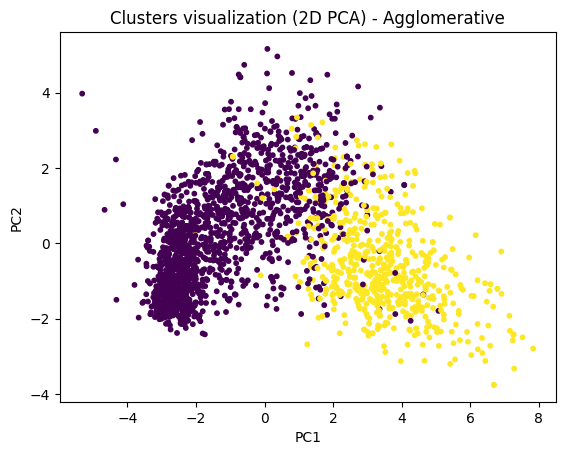

In [21]:
# =========================
# 9) Quick PCA visualization (2D)
# =========================
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_proc)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=10, c=df_out["Cluster"].values)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Clusters visualization (2D PCA) - {final_method}")
plt.show()

In [23]:
# =========================
# 10) Display clustered dataset + persona table
# =========================
from IPython.display import display

print("Cluster sizes:")
display(df_out["Cluster"].value_counts().sort_index())

print("\nPersona summary (cluster-wise means):")
display(cluster_profile)

print("\nSample of clustered dataset:")
display(df_out.head(10))

Cluster sizes:


,count
Cluster,
0,1620
1,605



Persona summary (cluster-wise means):


,Income,Age,Kidhome,Teenhome,Recency,TenureDays,MntWines,MntMeatProducts,MntGoldProds,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth,NumDealsPurchases,Response,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster,,,,,,,,,,,,,,,,,,,,
0,43019.59,55.66,0.60,0.60,49.20,522.26,189.86,67.73,31.66,3.64,4.81,1.53,6.17,2.65,0.10,0.00,0.00,0.08,0.05,0.00
1,74287.75,57.30,0.04,0.26,49.01,520.85,612.08,426.45,77.07,5.29,8.47,5.58,3.11,1.44,0.28,0.23,0.05,0.05,0.15,0.26



Sample of clustered dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,TenureDays,Age,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,0,0,0,0,0,0,1,971.0,68,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,0,0,0,0,0,0,0,125.0,71,0
2,4141,1965,Graduation,Together,71613.0,0,0,NaT,26,426,...,0,0,0,0,0,0,0,NaN,60,1
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,0,0,0,0,0,0,0,65.0,41,0
4,5324,1981,PhD,Married,58293.0,1,0,NaT,94,173,...,0,0,0,0,0,0,0,NaN,44,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,0,0,0,0,0,0,0,453.0,58,0
6,965,1971,Graduation,Divorced,55635.0,0,1,NaT,34,235,...,0,0,0,0,0,0,0,NaN,54,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-08-05,32,76,...,0,0,0,0,0,0,0,488.0,40,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,0,0,0,0,0,0,1,548.0,51,0
9,5899,1950,PhD,Together,5648.0,1,1,NaT,68,28,...,1,0,0,0,0,0,0,NaN,75,0


In [24]:
k = 5  # micro-segmentation target

from sklearn.cluster import AgglomerativeClustering
labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_pca)

df_out = df.copy()
df_out["Cluster"] = labels

cluster_profile = df_out.groupby("Cluster")[profile_cols].mean().round(2)
cluster_size = df_out["Cluster"].value_counts().sort_index()

print("Cluster sizes:")
display(cluster_size)

print("\nPersona summary:")
display(cluster_profile)

Cluster sizes:


,count
Cluster,
0,576
1,711
2,889
3,29
4,20



Persona summary:


,Income,Age,Kidhome,Teenhome,Recency,TenureDays,MntWines,MntMeatProducts,MntGoldProds,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth,NumDealsPurchases,Response,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster,,,,,,,,,,,,,,,,,,,,
0,74505.45,57.31,0.04,0.25,48.96,520.19,596.38,435.65,77.75,5.31,8.49,5.60,3.01,1.43,0.26,0.22,0.0,0.04,0.12,0.25
1,52616.36,58.53,0.38,0.79,45.47,592.38,365.41,118.84,51.79,5.37,6.55,2.74,5.97,3.51,0.22,0.00,0.0,0.18,0.10,0.00
2,35284.65,53.35,0.77,0.45,52.14,463.98,49.75,25.73,15.64,2.24,3.41,0.55,6.34,1.98,0.00,0.00,0.0,0.00,0.00,0.00
3,69963.90,57.07,0.07,0.45,50.17,547.67,923.86,243.62,63.59,4.86,8.00,5.03,5.28,1.72,0.66,0.41,1.0,0.24,0.72,0.55
4,45672.40,56.65,0.65,0.55,50.75,722.44,176.70,117.70,27.60,3.70,5.40,2.10,5.85,2.40,0.15,0.00,0.0,0.10,0.00,0.05


In [25]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
df["Dt_Customer"] = df["Dt_Customer"].fillna(df["Dt_Customer"].median())
df["TenureDays"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days